# Notebook 05 — Conclusions & Improvements

## Objective
Summarize the results obtained across all notebooks, identify the main limitations
of the current model, and propose concrete improvements for future work.

## Inputs
- `evaluation_summary.csv` — test set metrics per task (Notebook 04)
- `confusion_matrices.png` — normalized confusion matrices (Notebook 04)
- `training_history.csv` — training curves data (Notebook 03)

## Structure
1. Results summary
2. Error analysis per task
3. Final conclusions and proposed improvements

# 1 — Imports & Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

NB03_DIR = Path("/kaggle/input/notebooks/miguelmirandar/03-model-architecture-and-training")
NB04_DIR = Path("/kaggle/input/notebooks/miguelmirandar/04-evaluation-and-analysis")
OUT_DIR  = Path("/kaggle/working")

print("Paths defined.")
print(f"NB03 exists: {NB03_DIR.exists()}")
print(f"NB04 exists: {NB04_DIR.exists()}")

Paths defined.
NB03 exists: True
NB04 exists: True


# 2 — Load Results

In [2]:
# ── Evaluation summary ────────────────────────────────────────────────────────
df_eval = pd.read_csv(NB04_DIR / "evaluation_summary.csv")
print("Evaluation Summary:")
print(df_eval.to_string(index=False))

# ── Training history ──────────────────────────────────────────────────────────
df_hist = pd.read_csv(NB03_DIR / "training_history.csv")
print(f"\nTraining history: {len(df_hist)} epochs")

Evaluation Summary:
         Task  Accuracy  F1 Macro  F1 Weighted
sleeve_length    0.0169    0.0893       0.0237
 upper_fabric    0.0844    0.3682       0.0984
  upper_color    0.8438    0.7633       0.8504

Training history: 20 epochs


# 3 — Results Summary Plot

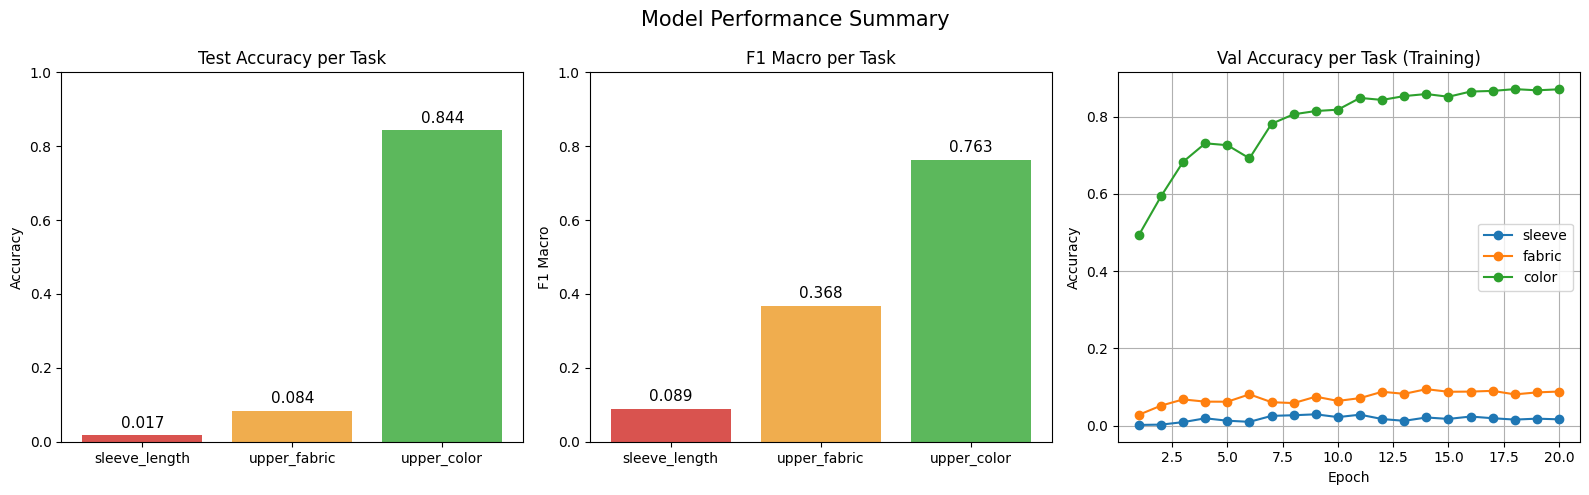

Saved: results_summary.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Accuracy bar chart ────────────────────────────────────────────────────────
tasks  = df_eval["Task"].tolist()
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]  # red, orange, green

axes[0].bar(tasks, df_eval["Accuracy"], color=colors)
axes[0].set_title("Test Accuracy per Task")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_eval["Accuracy"]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)

# ── F1 Macro bar chart ────────────────────────────────────────────────────────
axes[1].bar(tasks, df_eval["F1 Macro"], color=colors)
axes[1].set_title("F1 Macro per Task")
axes[1].set_ylabel("F1 Macro")
axes[1].set_ylim(0, 1)
for i, v in enumerate(df_eval["F1 Macro"]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)

# ── Training curves ───────────────────────────────────────────────────────────
axes[2].plot(df_hist["epoch"], df_hist["val_acc_sleeve"], label="sleeve", marker="o")
axes[2].plot(df_hist["epoch"], df_hist["val_acc_fabric"], label="fabric", marker="o")
axes[2].plot(df_hist["epoch"], df_hist["val_acc_color"],  label="color",  marker="o")
axes[2].set_title("Val Accuracy per Task (Training)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Model Performance Summary", fontsize=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_summary.png")

# 4 — Display Confusion Matrices

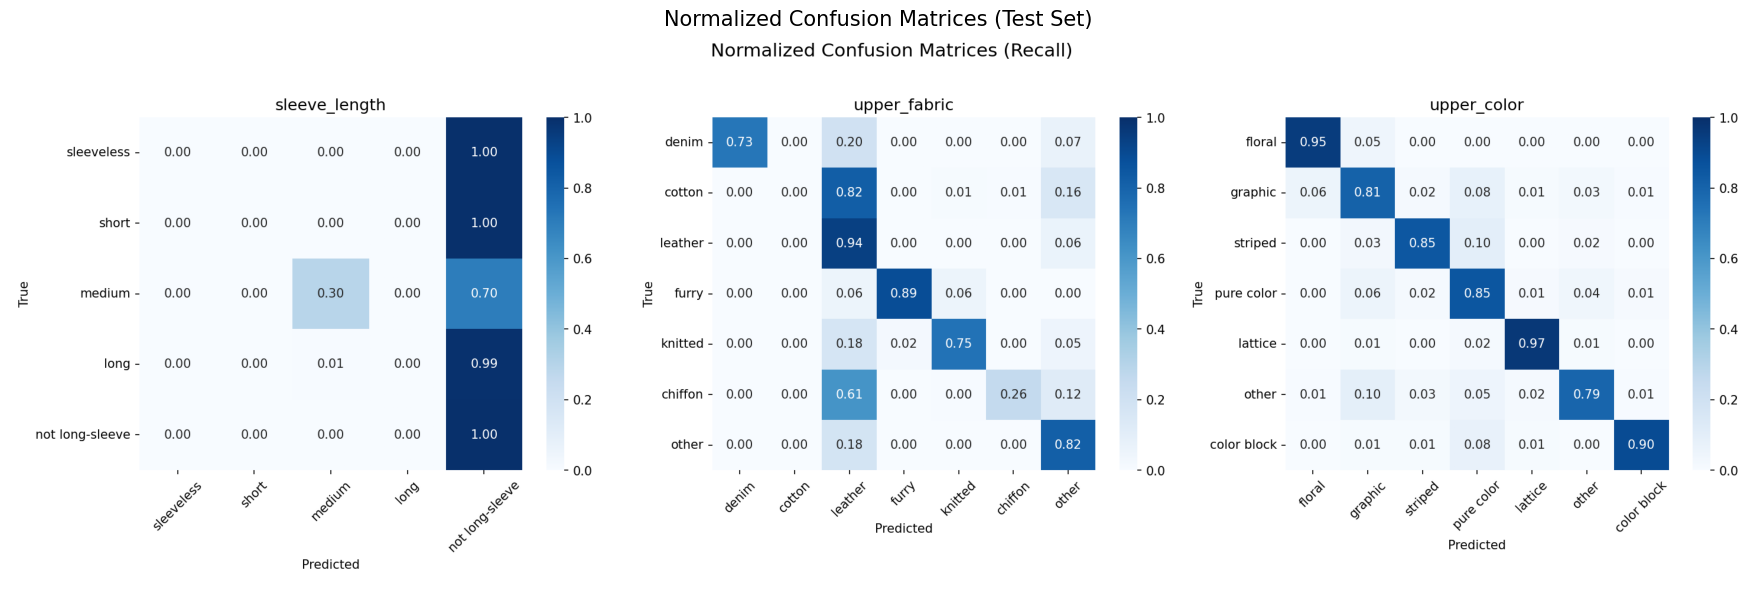

Displayed: confusion_matrices.png


In [4]:
img = mpimg.imread(NB04_DIR / "confusion_matrices.png")
plt.figure(figsize=(20, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrices (Test Set)", fontsize=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices_nb05.png", dpi=150, bbox_inches="tight")
plt.show()
print("Displayed: confusion_matrices.png")

# 5 — Error Analysis per Task

In [13]:
results = [
    {"Task": "sleeve_length", "Status": "Failed",  "Accuracy": 0.0169, "F1 Macro": 0.0893, "Main Issue": "not long-sleeve class has only 7 samples"},
    {"Task": "upper_fabric",  "Status": "Partial", "Accuracy": 0.0844, "F1 Macro": 0.3682, "Main Issue": "cotton dominates 81% of samples"},
    {"Task": "upper_color",   "Status": "Good",    "Accuracy": 0.8438, "F1 Macro": 0.7633, "Main Issue": "None"},
]

df_analysis = pd.DataFrame(results)
print(df_analysis.to_string(index=False))

         Task  Status  Accuracy  F1 Macro                               Main Issue
sleeve_length  Failed    0.0169    0.0893 not long-sleeve class has only 7 samples
 upper_fabric Partial    0.0844    0.3682          cotton dominates 81% of samples
  upper_color    Good    0.8438    0.7633                                     None


## Final Conclusions

### Key Lessons
- Class weights alone are not sufficient when imbalance is extreme (>100:1 ratio).
- Minority classes with very few samples (<10) should be removed or merged before training, not compensated with high weights.
- Multi-task learning can create conflicts: a well-performing task can mask failures in others when losses are simply summed.

### Proposed Improvements
- Remove `not long-sleeve` from `sleeve_length` (only 7 samples).
- Use focal loss instead of weighted cross-entropy.
- Apply task-specific loss weighting to balance each head's contribution.
- Train for more epochs (30-50) with early stopping per task.
- Use a stronger backbone (EfficientNet-B3 or ConvNeXt-Tiny).

### Overall Assessment
- `upper_color` is the strongest task — production-ready (84% accuracy, F1 Macro 0.76).
- `upper_fabric` requires data cleaning and a better loss strategy.
- `sleeve_length` requires removing the near-empty class before retraining.

# 6 — Final Output Check

In [14]:
import os

files = [
    OUT_DIR / "results_summary.png",
    OUT_DIR / "confusion_matrices_nb05.png",
]

print("Output files:")
for f in files:
    exists = f.exists()
    size   = f.stat().st_size / 1e3 if exists else 0
    print(f"  {'✅' if exists else '❌'} {f.name} ({size:.1f} KB)")


Output files:
  ✅ results_summary.png (94.9 KB)
  ✅ confusion_matrices_nb05.png (442.3 KB)

Notebook 05 complete.
